In [3]:
import pandas as pd 


## Gender quary 
```
PREFIX lrm: <http://iflastandards.info/ns/lrm/lrmoo/>
PREFIX sd: <https://r11.eu/rdf/resource/>
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX star: <https://r11.eu/ns/star/>
PREFIX sdhss: <https://r11.eu/ns/prosopography/>
select * where { 
     ?pnode a crm:E21_Person ;
         crm:P3_has_note ?person .
    ?a1 a star:E13_crm_P41 ;
    	crm:P141_assigned ?pnode ;
    	crm:P140_assigned_attribute_to ?intermidiet1.
    ?a2 a star:E13_crm_P42;
    	crm:P140_assigned_attribute_to ?intermidiet1;
    	crm:P141_assigned ?pre_gender.
    ?pre_gender crm:P1_is_identified_by ?gender.
    
      
} 
```


In [4]:
def get_data():
    data = pd.read_csv("data/query-result.csv")
    return data
data = get_data()
data.head()

,pnode,person,a1,kr,anode,snode,authority,a2,knode,kinsman,a3,kt,kinship
0,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",https://r11.eu/rdf/resource/c2557e72-877c-4d95...,https://r11.eu/rdf/resource/040129a5-d270-47a4...,https://r11.eu/rdf/resource/37ade4c7-baf2-4bec...,https://r11.eu/rdf/resource/2ca67aa0-2865-489a...,"Ioannes Skylitzes, historian",https://r11.eu/rdf/resource/395e8c9f-ee41-47ff...,https://r11.eu/rdf/resource/0f7afd6a-cdd8-4a6e...,"Alousianos, son of Ioannes/John Vladislav",https://r11.eu/rdf/resource/9f4cb43e-0574-4238...,https://r11.eu/rdf/resource/327507a9-575b-4770...,father (brother)
1,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",https://r11.eu/rdf/resource/c2557e72-877c-4d95...,https://r11.eu/rdf/resource/040129a5-d270-47a4...,https://r11.eu/rdf/resource/37ade4c7-baf2-4bec...,https://r11.eu/rdf/resource/2ca67aa0-2865-489a...,"Ioannes Skylitzes, historian",https://r11.eu/rdf/resource/d0249602-4e27-4f29...,https://r11.eu/rdf/resource/0f7afd6a-cdd8-4a6e...,"Alousianos, son of Ioannes/John Vladislav",https://r11.eu/rdf/resource/9f4cb43e-0574-4238...,https://r11.eu/rdf/resource/327507a9-575b-4770...,father (brother)
2,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",https://r11.eu/rdf/resource/1e72cf30-435d-4e18...,https://r11.eu/rdf/resource/040129a5-d270-47a4...,https://r11.eu/rdf/resource/7231f2c2-e72b-4cd6...,https://r11.eu/rdf/resource/5e0cf666-5cc7-4b8d...,Ioannes Zonaras,https://r11.eu/rdf/resource/395e8c9f-ee41-47ff...,https://r11.eu/rdf/resource/0f7afd6a-cdd8-4a6e...,"Alousianos, son of Ioannes/John Vladislav",https://r11.eu/rdf/resource/9f4cb43e-0574-4238...,https://r11.eu/rdf/resource/327507a9-575b-4770...,father (brother)
3,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",https://r11.eu/rdf/resource/1e72cf30-435d-4e18...,https://r11.eu/rdf/resource/040129a5-d270-47a4...,https://r11.eu/rdf/resource/7231f2c2-e72b-4cd6...,https://r11.eu/rdf/resource/5e0cf666-5cc7-4b8d...,Ioannes Zonaras,https://r11.eu/rdf/resource/d0249602-4e27-4f29...,https://r11.eu/rdf/resource/0f7afd6a-cdd8-4a6e...,"Alousianos, son of Ioannes/John Vladislav",https://r11.eu/rdf/resource/9f4cb43e-0574-4238...,https://r11.eu/rdf/resource/327507a9-575b-4770...,father (brother)
4,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",https://r11.eu/rdf/resource/c2557e72-877c-4d95...,https://r11.eu/rdf/resource/040129a5-d270-47a4...,https://r11.eu/rdf/resource/37ade4c7-baf2-4bec...,https://r11.eu/rdf/resource/2ca67aa0-2865-489a...,"Ioannes Skylitzes, historian",https://r11.eu/rdf/resource/395e8c9f-ee41-47ff...,https://r11.eu/rdf/resource/0f7afd6a-cdd8-4a6e...,"Alousianos, son of Ioannes/John Vladislav",https://r11.eu/rdf/resource/30834ba5-213c-4931...,https://r11.eu/rdf/resource/327507a9-575b-4770...,father (brother)


In [5]:
# extract pnode, persnon, knode,kinsman, kt, kinship 
cuted_data = data[['pnode', 'person', 'knode', 'kinsman', 'kt', 'kinship']]
print(cuted_data.shape)

(122473, 6)


In [6]:
# leave only unique rows 
cuted_data = cuted_data.drop_duplicates()
print(cuted_data.shape)

(3498, 6)


In [8]:
# check what relations we hve 
unique_relations_list = cuted_data['kinship'].value_counts()
# get unique relations names 
unique_relations = unique_relations_list.keys()
print(unique_relations)

Index(['father', 'son', 'brother', 'husband', 'wife', 'mother', 'daughter',
       'kin', 'uncle', 'nephew',
       ...
       'spiritual nephew', 'nephew (cousin)', 'daughter (younger)',
       'spiritual uncle', 'relative (aunt) by marriage',
       'husband (by illicit marriage)', 'relative (nephew) by marriage',
       'wife (by illicit marriage)', 'daughter (adopted)', 'man'],
      dtype='object', name='kinship', length=149)


In [8]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ----------- ---------------------------- 81.9/294.9 kB 1.1 MB/s eta 0:00:01
   ------------------------------ --------- 225.3/294.9 kB 1.7 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 k

C:\Users\ja.borowski\AppData\Local\Temp\ipykernel_58760\2272180725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kinship_counts.index, y=kinship_counts.values, palette="viridis")


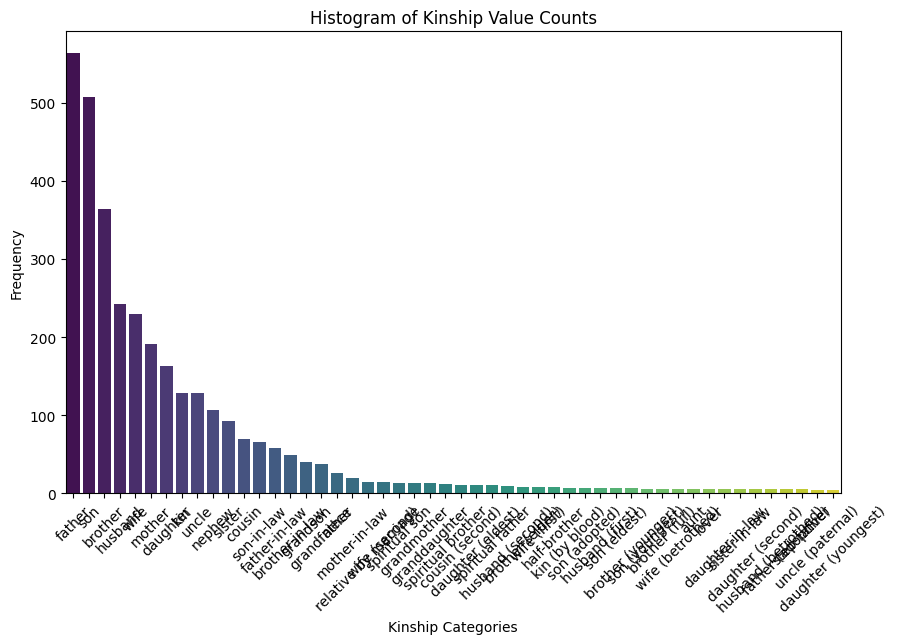

In [9]:
# make a plot of relation popularity 
import matplotlib.pyplot as plt
import seaborn as sns
kinship_counts = cuted_data['kinship'].value_counts().iloc[:50]

# Create the histogram plot
plt.figure(figsize=(10, 6))
sns.barplot(x=kinship_counts.index, y=kinship_counts.values, palette="viridis")

# Labeling the plot
plt.xlabel("Kinship Categories")
plt.ylabel("Frequency")
plt.title("Histogram of Kinship Value Counts")
plt.xticks(rotation=45)  # Rotate labels for better readability

# Show the plot
plt.show()

In [10]:
kinship_names = cuted_data['kinship'].value_counts().iloc[:50].index.tolist()
print(kinship_names)
# remove not reale realtions 
#'spiritual son
# spiritual brother
# spiritual father
# son (adopted)
# lover

chosen_kinships = [i for i in kinship_names if i not in ["spiritual son","spiritual brother","spiritual father","son (adopted)","lover"]]

['father', 'son', 'brother', 'husband', 'wife', 'mother', 'daughter', 'kin', 'uncle', 'nephew', 'sister', 'cousin', 'son-in-law', 'father-in-law', 'brother-in-law', 'grandson', 'grandfather', 'niece', 'mother-in-law', 'relative by marriage', 'wife (second)', 'spiritual son', 'grandmother', 'granddaughter', 'spiritual brother', 'cousin (second)', 'daughter (eldest)', 'spiritual father', 'husband (second)', 'brother (elder)', 'wife (first)', 'half-brother', 'kin (by blood)', 'son (adopted)', 'husband (first)', 'son (eldest)', 'brother (younger)', 'son (youngest)', 'brother (full)', 'wife (betrothed)', 'aunt', 'lover', 'daughter-in-law', 'sister-in-law', 'daughter (second)', 'husband (betrothed)', 'father (adoptive)', 'step-father', 'uncle (paternal)', 'daughter (youngest)']


In [11]:
## load maping from a file 
mapping = pd.read_csv("data/relation_map.csv",sep=';')
mapping = mapping[mapping["Set 1"].isin(chosen_kinships)]
mapping

# 

,Set 1,Set 2
0,father,FatherOf
1,son,SonOf
2,brother,BrotherOf
3,husband,HusbandOf
4,wife,WifeOf
5,mother,MotherOf
6,daughter,DaughterOf
7,kin,RelativeOf
8,uncle,UncleOf
9,nephew,NephewOf


In [14]:
# convert mapping into a dictionary 
mapping_dict = dict(zip(mapping['Set 1'], mapping['Set 2']))

In [13]:
# generate csv with new relations 
cuted_data['ontology_kinship']= cuted_data['kinship'].map(mapping_dict)

In [15]:
## get gender data 
gender_data = pd.read_csv("data/gender_query.csv")
print(f"Pre cut size {gender_data.shape}")
cut_gender_data = gender_data[['pnode', 'person','gender']]
cut_gender_data = cut_gender_data.drop_duplicates()
print(f"Post cut size {cut_gender_data.shape}")
cut_gender_data.head()


Pre cut size (9273, 7)
Post cut size (9270, 3)


,pnode,person,gender
0,https://r11.eu/rdf/resource/6f21cc33-baa9-417f...,"Aaron, brother of Alousianos",Male
1,https://r11.eu/rdf/resource/d0fc20c8-1dbd-4411...,"Aaron, father of paroikos Demetrios at Kamena",Male
2,https://r11.eu/rdf/resource/3d45ce41-12d7-4374...,"Abasgos, servant of Eustathios Boilas",Male
3,https://r11.eu/rdf/resource/a855b02a-e7c7-4946...,"Abimelech, brother of Qutlumish",Male
4,https://r11.eu/rdf/resource/55bdd4b9-4a34-48d4...,"Ibrahim Yinal, half-brother of Tughrul Beg",Male


In [16]:
# right join with cuted data 
merged_data = pd.merge(cuted_data, cut_gender_data , on="pnode", how="left")
cut_merged_data = merged_data[['pnode', 'person_x', 'knode', 'kinsman', 'kinship', 'ontology_kinship','gender']]


In [17]:
# raname column 
cut_merged_data = cut_merged_data.rename(columns={'gender': 'person_gender'})

In [18]:
# add gender fot a kinsman 
full_merged_data = pd.merge(cut_merged_data,cut_gender_data,left_on="knode",right_on='pnode', how="left")

In [19]:
full_merged_data = full_merged_data.rename(columns={'gender': 'kinsman_gender'})

In [20]:
# remove unacepted characters
full_merged_data['person_x'] = full_merged_data['person_x'].str.replace('"', '')
full_merged_data['kinsman'] = full_merged_data['kinsman'].str.replace('"', '')

In [21]:
subset_for_export = full_merged_data[['person_x','kinsman','person_gender','kinsman_gender']]

In [22]:
## export two files

subset = subset_for_export[["person_x","person_gender"]]

# do v-stack
subset = subset.rename(columns={"person_x":"person","person_gender":"gender"})
gender_data_export=pd.concat([subset,subset_for_export[["kinsman","kinsman_gender"]].rename(columns={"kinsman":"person","kinsman_gender":"gender"})], ignore_index=True)
gender_data_export = gender_data_export.drop_duplicates()
# drop NA 
gender_data_export = gender_data_export.dropna()
gender_data_export.to_excel("data/gender_data_export.xlsx",index=False)

In [23]:
# gender_data_export
full_merged_data[['person_x','kinsman','person_gender','kinsman_gender',"ontology_kinship"]].to_excel("data/merged_data_export.xlsx",index=False)

In [24]:
# count values in columns 
relation_data = full_merged_data[["person_x","kinsman","ontology_kinship"]]
relation_data.drop_duplicates().to_excel("data/relation_data_export.xlsx",index=False)

In [25]:
final_data=full_merged_data[['person_x','kinsman','person_gender','kinsman_gender',"ontology_kinship"]]
final_data.drop_duplicates(inplace=True)
final_data.dropna(inplace=True)
final_data.to_excel("data/final_data_export.xlsx",index=False)

C:\Users\ja.borowski\AppData\Local\Temp\ipykernel_58760\1937799759.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data.drop_duplicates(inplace=True)
C:\Users\ja.borowski\AppData\Local\Temp\ipykernel_58760\1937799759.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_data.dropna(inplace=True)


### Add formulas rule 1 
Individual: @A*
 Types: @C*
Facts: @E*(ObjectProperty) @B*
### Rule 2 
Individual: @B*
 Types: @D*


In [36]:
final_data

,person_x,kinsman,person_gender,kinsman_gender,ontology_kinship
2,"Aaron, brother of Alousianos","John Vladislav, ruler of Bulgaria",Male,Male,SonOf
3,"Adrianos Komnenos, brother of Alexios I",Anna Dalassene,Male,Female,SonOf
4,"Akindynos, tax-payer at chorion of Dobrobikeia","Kaletza, mother of tax-payer at Dobrobikeia",Male,Female,SonOf
5,"'Allaf, son of Hassan ibn al-Mufarrij",Hassan ibn al-Mufarrij ibn al-Jarrah (Pinzarach),Male,Male,SonOf
6,Emperor Alexios I Komnenos,Anna Dalassene,Male,Female,SonOf
...,...,...,...,...,...
3424,"Eudokia Komnene, sister of Alexios I, wife of ...","Ioannes Komnenos, father of Alexios I",Female,Male,DaughterOf
3425,"Anna Doukaina, sister of Eirene Doukaina and w...","Andronikos Doukas, son of the kaisar Ioannes",Female,Male,DaughterOf
3426,"Anna Doukaina, sister of Eirene Doukaina and w...","Maria of Bulgaria, wife of Andronikos Doukas",Female,Female,DaughterOf
3443,"Romuald, prominent person in Bari, full brothe...","Petros, prominent person in Bari, full brother...",Male,Male,BrotherOf
